# Logit lens -- analysis

Reads the per-layer curves from `logit-lens-v2/` and answers: **at which layers do flipping items
diverge from stable ones between peak and trough?**

**Layer numbering.** Lens layer `l` = the residual stream after `l` transformer blocks
(`l = 0` is the embeddings, `l = 32` the final output). So lens layer 19 is the output of
`model.model.layers[18]` -- use that index when patching.

**Groups** (capitals only, per run and seed), from the lens's final layer -- the model's actual
first-token choice -- so seeds without eval results work too:
- *flip*: `D_final > 0` at peak, `< 0` at trough
- *flip_recovered* (tulu): flip, and `D_final > 0` again at recovery
- *stable*: `D_final > 0` at every phase

**Scale correction.** Logits grow with training (mean |D_final| over all items: 3.4 at tulu peak,
6.0 at recovery), which inflates changes for items that already lean strongly. So every checkpoint's
`D` is divided, layer by layer, by its root-mean-square over **all** items at that checkpoint.
Sign is kept (`> 0` still means context).

**Statistic**, comparison from phase A to phase B, per layer `l`:

    delta_D[l](item) = D_B[l](item) - D_A[l](item)
    DiD[l]           = mean over flips of delta_D[l]  -  mean over stable of delta_D[l]

95% CI by bootstrapping items (2000 resamples).
- *peak layer*: the layer with the largest |DiD| (the effect peaks mid-late and fades toward the output)
- *onset layer*: first layer from which the CI excludes 0 all the way up to the peak layer
- *half layer*: first layer where DiD reaches half of its peak value
- *profile*: `DiD[l] / DiD[peak]`

**Replication criteria -- revised 2026-09-29 after the seed-0 exploratory run, then frozen.**
The first version used raw logits and anchored on the final layer; seed 0 showed both were wrong
(logit growth, and an effect that peaks at layers ~20-26 and fades). Seed 0 is therefore
*exploratory*; other seeds are the *confirmatory* test of these frozen criteria:
1. Validation: final-layer lean agrees with the generated answer on >= 90% of items (seed 0).
2. Every comparison (tulu drop, tulu recovery, alpaca drop) x every seed: DiD at its peak layer has a
   CI excluding 0, in the expected direction (drop < 0, recovery > 0).
3. The half layers of all comparisons x seeds lie within 3 layers of each other.
4. Every profile correlates >= 0.9 with the seed-0 tulu-drop profile.

In [1]:
import json, glob, os
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu

# Runs locally (CPU, seconds) from src/mechanistic-analysis/, or in Colab reading straight from Drive.
if os.path.isdir("/content/drive/MyDrive"):
    os.chdir("/content/context-parametric-inversion-research/src/mechanistic-analysis")
    LENS_DIR = "/content/drive/MyDrive/CPI-Analysis-Results/logit-lens-v2"
else:
    LENS_DIR = "logit-lens-v2"       # the Drive folder, downloaded next to this notebook
assert glob.glob(f"{LENS_DIR}/*.json"), f"no lens files in {os.path.abspath(LENS_DIR)}"
assert os.path.exists("flip_set.json"), "flip_set.json missing -- in Colab it must be pushed to GitHub first"

PHASES = {"tulu": ["peak", "trough", "recovery"], "alpaca": ["peak", "trough"]}

# RAW[(run, seed, phase)] = {item_id: D per layer}. Items whose two answers share a first token are
# dropped (their D is 0 by construction).
RAW, STEP = {}, {}
for f in sorted(glob.glob(f"{LENS_DIR}/*.json")):
    d = json.load(open(f, encoding="utf-8"))
    key = (d["run"], d["seed"], d["phase"])
    RAW[key] = {i: np.array(v["D"]) for i, v in d["curves"].items() if not v["same_first_token"]}
    STEP[key] = d["step"]

# Scale correction: divide each layer by its RMS over all items at that checkpoint.
LENS = {}
for key, curves in RAW.items():
    rms = np.sqrt(np.mean([D ** 2 for D in curves.values()], axis=0))
    rms[rms == 0] = 1.0
    LENS[key] = {i: D / rms for i, D in curves.items()}

N_LAYERS = len(next(iter(next(iter(RAW.values())).values())))
SEEDS = {run: sorted({s for (r, s, p) in RAW if r == run}) for run in PHASES}
for key in sorted(RAW):
    print(key, "step", STEP[key], "-", len(RAW[key]), "items")
print("layers per curve:", N_LAYERS, "  seeds:", SEEDS)

('alpaca', 0, 'peak') step 100 - 376 items
('alpaca', 0, 'trough') step 700 - 376 items
('tulu', 0, 'peak') step 500 - 376 items
('tulu', 0, 'recovery') step 5000 - 376 items
('tulu', 0, 'trough') step 3150 - 376 items
layers per curve: 33   seeds: {'tulu': [0], 'alpaca': [0]}


## Validation (seed 0)
Same prompt and greedy decoding as the eval, so the final layer must point to the answer the model
actually generated, for every item whose stored generation starts with one of the two answers.

In [2]:
def generated_answer(run, step):
    # which answer the stored greedy generation starts with: "cf", "par", or None (something else)
    f = f"../../results/cpi-results/{run}-results/checkpoint_step{step}_metrics.json"
    out = {}
    for r in json.load(open(f, encoding="utf-8"))["per_item"]:
        resp, cf, par = r["response"].strip(), r["counterfactual_answer"].strip(), r["parametric_answer"].strip()
        out[r["item_id"]] = "cf" if resp.startswith(cf) else ("par" if resp.startswith(par) else None)
    return out

print("all values finite:", all(np.isfinite(D).all() for c in RAW.values() for D in c.values()))
for run in PHASES:
    for phase in PHASES[run]:
        key = (run, 0, phase)
        if key not in RAW:
            continue
        said = generated_answer(run, STEP[key])
        pairs = [(RAW[key][i][-1] > 0, said[i] == "cf") for i in RAW[key] if said.get(i)]
        agree = sum(a == b for a, b in pairs) / len(pairs)
        print(f"{run:6s} {phase:8s} step {STEP[key]:5d}: final-layer lean agrees with generated answer "
              f"on {agree:.1%} of {len(pairs)} items  {'OK' if agree >= 0.9 else 'FAIL'}")

all values finite: True
tulu   peak     step   500: final-layer lean agrees with generated answer on 98.5% of 331 items  OK
tulu   trough   step  3150: final-layer lean agrees with generated answer on 98.8% of 346 items  OK
tulu   recovery step  5000: final-layer lean agrees with generated answer on 98.3% of 347 items  OK
alpaca peak     step   100: final-layer lean agrees with generated answer on 99.7% of 364 items  OK
alpaca trough   step   700: final-layer lean agrees with generated answer on 99.1% of 343 items  OK


## Groups
From the lens final layer, capitals only. For seed 0, also compared with the eval-based robust flips.

In [3]:
def lens_groups(run, seed):
    phases = PHASES[run]
    ids = [i for i in RAW[(run, seed, phases[0])] if i.startswith("cap_")
           and all(i in RAW[(run, seed, p)] for p in phases)]
    final = {p: {i: RAW[(run, seed, p)][i][-1] for i in ids} for p in phases}
    groups = {"flip":   [i for i in ids if final["peak"][i] > 0 and final["trough"][i] < 0],
              "stable": [i for i in ids if all(final[p][i] > 0 for p in phases)]}
    if "recovery" in phases:
        groups["flip_recovered"] = [i for i in groups["flip"] if final["recovery"][i] > 0]
    return groups

GROUPS = {(run, seed): lens_groups(run, seed) for run in PHASES for seed in SEEDS[run]}
for (run, seed), g in GROUPS.items():
    print(run, "seed", seed, {k: len(v) for k, v in g.items()})

flip_set = json.load(open("flip_set.json"))
for run in PHASES:
    if (run, 0) not in GROUPS:
        continue
    robust = {r["item_id"] for name, rows in flip_set[run]["groups"].items() if name.startswith("flip")
              for r in rows if r["robust"] and r["stratum"] == "cap"}
    lens_flip = set(GROUPS[(run, 0)]["flip"])
    print(f"{run} seed 0: lens flips contain {len(robust & lens_flip)}/{len(robust)} of the eval robust flips; "
          f"{len(lens_flip - robust)} lens flips are not robust eval flips")

tulu seed 0 {'flip': 59, 'stable': 98, 'flip_recovered': 36}
alpaca seed 0 {'flip': 36, 'stable': 130}
tulu seed 0: lens flips contain 44/50 of the eval robust flips; 15 lens flips are not robust eval flips
alpaca seed 0: lens flips contain 20/27 of the eval robust flips; 16 lens flips are not robust eval flips


## Difference-in-differences per layer

In [4]:
def item_deltas(run, seed, phase_a, phase_b, ids):
    A, B = LENS[(run, seed, phase_a)], LENS[(run, seed, phase_b)]
    return np.array([B[i] - A[i] for i in ids])            # items x layers

def did_curve(dF, dS, n_boot=2000):
    did = dF.mean(0) - dS.mean(0)
    rng = np.random.default_rng(0)
    boots = np.array([dF[rng.integers(0, len(dF), len(dF))].mean(0) - dS[rng.integers(0, len(dS), len(dS))].mean(0)
                      for _ in range(n_boot)])
    lo, hi = np.percentile(boots, [2.5, 97.5], axis=0)
    return did, lo, hi

def peak_layer(did):
    return int(np.argmax(np.abs(did[1:]))) + 1               # skip the embeddings

def onset_layer(did, lo, hi, pk):
    # first layer from which the CI excludes 0 (in the direction of the peak effect) up to the peak layer
    excludes = (hi < 0) if did[pk] < 0 else (lo > 0)
    for l in range(pk + 1):
        if excludes[l:pk + 1].all():
            return l
    return None

def half_layer(did, pk):
    return int(np.argmax(did / did[pk] >= 0.5))

COMPARISONS = [("tulu", "peak", "trough", "flip", "drop"),
               ("tulu", "trough", "recovery", "flip_recovered", "recovery"),
               ("alpaca", "peak", "trough", "flip", "drop")]

RESULTS = []
for run, a, b, flip_group, kind in COMPARISONS:
    for seed in SEEDS[run]:
        g = GROUPS[(run, seed)]
        if len(g[flip_group]) < 5:
            print(f"skip {run} seed {seed} {a}->{b}: only {len(g[flip_group])} flips")
            continue
        dF = item_deltas(run, seed, a, b, g[flip_group])
        dS = item_deltas(run, seed, a, b, g["stable"])
        did, lo, hi = did_curve(dF, dS)
        pk = peak_layer(did)
        RESULTS.append({"name": f"{run} {a}->{b}", "run": run, "seed": seed, "kind": kind,
                        "n_flip": len(dF), "n_stable": len(dS), "dF": dF, "dS": dS,
                        "did": did, "lo": lo, "hi": hi, "peak": pk,
                        "onset": onset_layer(did, lo, hi, pk), "half": half_layer(did, pk)})

print(f"{'comparison':22s} {'seed':>4s} {'flips':>5s} {'stable':>6s} {'DiD at peak layer [95% CI]':>28s} {'peak':>4s} {'onset':>5s} {'half':>4s}")
for r in RESULTS:
    pk = r["peak"]
    ci = f"{r['did'][pk]:+.2f} [{r['lo'][pk]:+.2f}, {r['hi'][pk]:+.2f}]"
    print(f"{r['name']:22s} {r['seed']:4d} {r['n_flip']:5d} {r['n_stable']:6d} {ci:>28s} {pk:4d} {str(r['onset']):>5s} {r['half']:4d}")

comparison             seed flips stable   DiD at peak layer [95% CI] peak onset half
tulu peak->trough         0    59     98         -0.52 [-0.67, -0.37]   20    19   20
tulu trough->recovery     0    36     98         +0.31 [+0.20, +0.42]   23    18   19
alpaca peak->trough       0    36    130         -0.44 [-0.59, -0.31]   22    19   19


## Replication check (frozen criteria 2-4)

In [5]:
ref = next(r for r in RESULTS if r["name"] == "tulu peak->trough" and r["seed"] == 0)
ref_profile = ref["did"] / ref["did"][ref["peak"]]

ok_direction = all((r["hi"][r["peak"]] < 0) if r["kind"] == "drop" else (r["lo"][r["peak"]] > 0) for r in RESULTS)
halves = [r["half"] for r in RESULTS]
ok_layers = max(halves) - min(halves) <= 3
corrs = {f"{r['name']} seed {r['seed']}": np.corrcoef(ref_profile, r["did"] / r["did"][r["peak"]])[0, 1] for r in RESULTS}
ok_shape = all(c >= 0.9 for c in corrs.values())

print(f"2. effect at peak layer significant, expected direction, everywhere: {ok_direction}")
print(f"3. half layers {halves} -> spread {max(halves) - min(halves)} (<= 3): {ok_layers}")
print("4. profile correlation with seed-0 tulu drop:")
for k, c in corrs.items():
    print(f"     {k:30s} r = {c:.2f}")
print(f"   all >= 0.9: {ok_shape}")
n_seeds = max(len(SEEDS[run]) for run in PHASES)
verdict = "REPLICATES" if (ok_direction and ok_layers and ok_shape) else "DOES NOT REPLICATE -- see which criterion failed"
print(f"\n{verdict}" + ("   (seed 0 only: exploratory, not confirmatory)" if n_seeds == 1 else ""))

2. effect at peak layer significant, expected direction, everywhere: True
3. half layers [20, 19, 19] -> spread 1 (<= 3): True
4. profile correlation with seed-0 tulu drop:
     tulu peak->trough seed 0       r = 1.00
     tulu trough->recovery seed 0   r = 0.86
     alpaca peak->trough seed 0     r = 0.92
   all >= 0.9: False

DOES NOT REPLICATE -- see which criterion failed   (seed 0 only: exploratory, not confirmatory)


## Focus: layers 19-26
Where exactly inside the window the effect sits, and whether it is carried by most flipping items
or by a few. Per item, `m` = mean scale-corrected change over layers 19-26; flips should mostly have
`m` in the expected direction, stable items much less so.

In [6]:
WINDOW = list(range(19, 27))

print("DiD per layer [95% CI]")
print(f"{'layer':>5s}  " + "  ".join(f"{r['name'] + ' s' + str(r['seed']):>26s}" for r in RESULTS))
for l in WINDOW:
    print(f"{l:5d}  " + "  ".join(f"{r['did'][l]:+.2f} [{r['lo'][l]:+.2f},{r['hi'][l]:+.2f}]".rjust(26) for r in RESULTS))

print("\nper-item mean change over layers 19-26")
for r in RESULTS:
    mF, mS = r["dF"][:, WINDOW].mean(1), r["dS"][:, WINDOW].mean(1)
    sign = -1 if r["kind"] == "drop" else 1
    fF, fS = np.mean(sign * mF > 0), np.mean(sign * mS > 0)
    p = mannwhitneyu(mF, mS).pvalue
    print(f"  {r['name']:22s} seed {r['seed']}: moves in expected direction -- flips {fF:.0%}, stable {fS:.0%}"
          f"   (Mann-Whitney p = {p:.1e})")

DiD per layer [95% CI]
layer        tulu peak->trough s0    tulu trough->recovery s0      alpaca peak->trough s0
   19         -0.20 [-0.33,-0.07]         +0.23 [+0.15,+0.31]         -0.30 [-0.43,-0.19]
   20         -0.52 [-0.67,-0.37]         +0.29 [+0.16,+0.43]         -0.40 [-0.51,-0.29]
   21         -0.46 [-0.60,-0.34]         +0.30 [+0.17,+0.41]         -0.42 [-0.53,-0.32]
   22         -0.46 [-0.60,-0.32]         +0.31 [+0.18,+0.43]         -0.44 [-0.59,-0.31]
   23         -0.41 [-0.53,-0.28]         +0.31 [+0.20,+0.42]         -0.40 [-0.53,-0.28]
   24         -0.37 [-0.47,-0.26]         +0.25 [+0.15,+0.34]         -0.39 [-0.50,-0.28]
   25         -0.39 [-0.50,-0.28]         +0.23 [+0.12,+0.33]         -0.38 [-0.50,-0.28]
   26         -0.37 [-0.47,-0.26]         +0.22 [+0.12,+0.32]         -0.33 [-0.44,-0.23]

per-item mean change over layers 19-26
  tulu peak->trough      seed 0: moves in expected direction -- flips 100%, stable 88%   (Mann-Whitney p = 3.8e-10)
  tulu trou

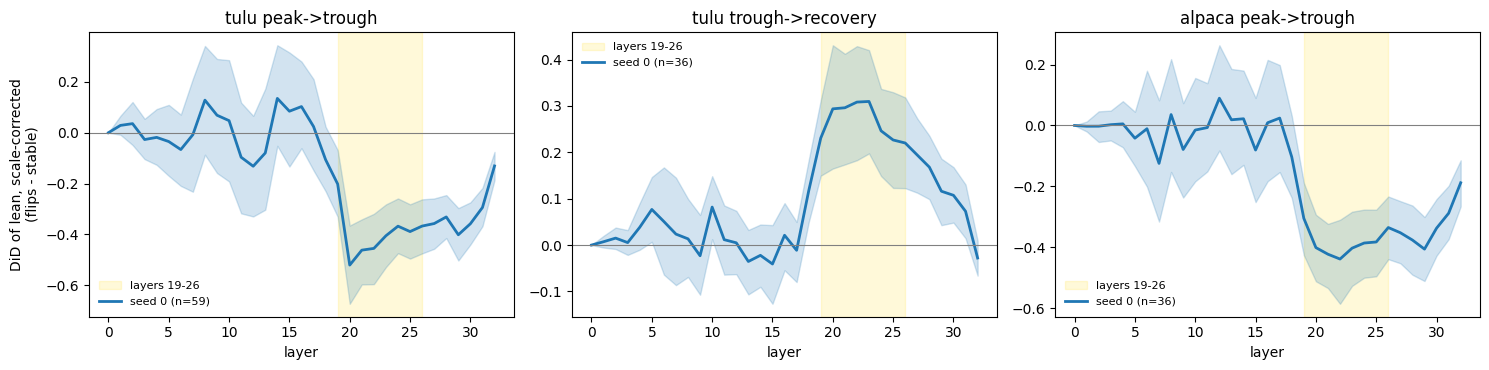

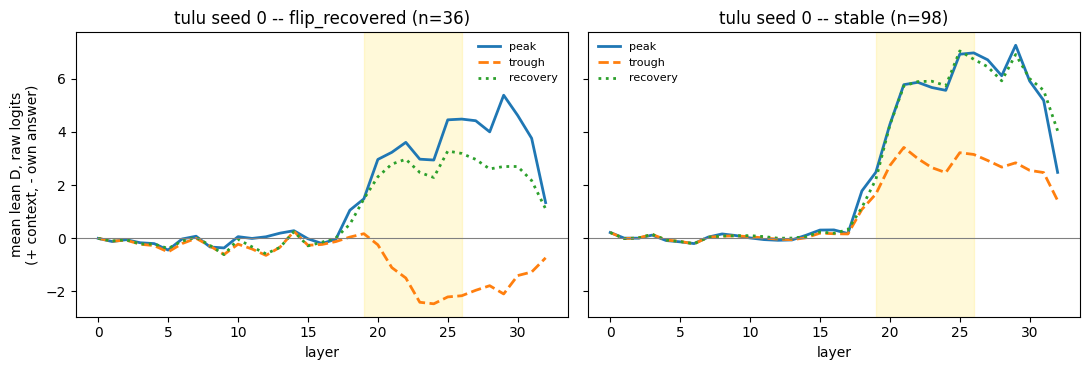

In [7]:
# Figure A: scale-corrected DiD per layer with 95% CI; layers 19-26 shaded.
names = list(dict.fromkeys(r["name"] for r in RESULTS))
fig, axes = plt.subplots(1, len(names), figsize=(5 * len(names), 3.8), sharex=True)
for ax, name in zip(np.atleast_1d(axes), names):
    ax.axvspan(19, 26, color="gold", alpha=0.15, label="layers 19-26")
    for r in [r for r in RESULTS if r["name"] == name]:
        x = np.arange(len(r["did"]))
        line, = ax.plot(x, r["did"], linewidth=2, label=f"seed {r['seed']} (n={r['n_flip']})")
        ax.fill_between(x, r["lo"], r["hi"], color=line.get_color(), alpha=0.2)
    ax.axhline(0, color="gray", linewidth=0.8)
    ax.set_title(name)
    ax.set_xlabel("layer")
    ax.legend(frameon=False, fontsize=8)
np.atleast_1d(axes)[0].set_ylabel("DiD of lean, scale-corrected\n(flips - stable)")
fig.tight_layout()
plt.show()

# Figure B: what the model leans to at each layer (raw logits), seed-0 tulu, flips vs stable.
g = GROUPS[("tulu", 0)]
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8), sharey=True)
for ax, group in zip(axes, ["flip_recovered", "stable"]):
    ax.axvspan(19, 26, color="gold", alpha=0.15)
    for phase, style in [("peak", "-"), ("trough", "--"), ("recovery", ":")]:
        mean = np.mean([RAW[("tulu", 0, phase)][i] for i in g[group]], axis=0)
        ax.plot(mean, style, linewidth=2, label=phase)
    ax.axhline(0, color="gray", linewidth=0.8)
    ax.set_title(f"tulu seed 0 -- {group} (n={len(g[group])})")
    ax.set_xlabel("layer")
    ax.legend(frameon=False, fontsize=8)
axes[0].set_ylabel("mean lean D, raw logits\n(+ context, - own answer)")
fig.tight_layout()
plt.show()